# 🔭 06 — Prévision 2023
## Holt-Winters + Prophet + Ensemble + Bootstrap IC

Ce notebook utilise les modèles entraînés sur 2018-2022 pour prévoir 2023 avec intervalles de confiance bootstrap.

## 1. 📦 Imports & Chargement

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

print("✅ Imports OK")

✅ Imports OK


In [ ]:
# Charger les données complètes
df = pd.read_csv("prepared_data.csv", index_col=0, parse_dates=True)
test = pd.read_csv("test_data.csv", index_col=0, parse_dates=True)

print(f"✅ Données chargées : {len(df)} mois (2018-2022)")
print(f"   Test 2022 : {len(test)} mois")

✅ Données chargées : 48 mois (2018-2022)
   Test 2022 : 12 mois


## 2. 📈 Holt-Winters 2023 + Bootstrap IC

In [13]:
# Holt-Winters sur toutes les données
hw_full = ExponentialSmoothing(df["revenue"], trend="add",
                                seasonal="multiplicative", seasonal_periods=12,
                                damped_trend=True).fit(optimized=True, use_brute=True)

forecast_hw = hw_full.forecast(12)
forecast_hw.index = pd.date_range("2023-01-01", periods=12, freq="MS")

# Bootstrap des résidus pour IC
rng = np.random.default_rng(42)
residuals = hw_full.resid.dropna()
simulations = np.array([rng.choice(residuals, size=12, replace=True) for _ in range(1000)])
simulations += forecast_hw.values

ic_low = np.percentile(simulations, 2.5, axis=0)
ic_high = np.percentile(simulations, 97.5, axis=0)

print("✅ Holt-Winters 2023 prêt")
print(f"   Total 2023 estimé : {forecast_hw.sum()/1e6:.2f}M€")

✅ Holt-Winters 2023 prêt
   Total 2023 estimé : 1133.81M€


## 3. 🤝 Ensemble 2023 & Visualisation

In [ ]:
# ── Holt-Winters uniquement (meilleur modèle) ───────────
# Prophet et SARIMA supprimés (performances insuffisantes)
# Bootstrap IC conservé

print("📊 Prévision 2023 — Holt-Winters (MAPE 4.92%)")

ensemble_2023 = forecast_hw.values
ic_low_ens = ic_low
ic_high_ens = ic_high

18:23:48 - cmdstanpy - INFO - Chain [1] start processing
18:23:49 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet 2023 prêt
   Total 2023 estimé : 1002.98M€


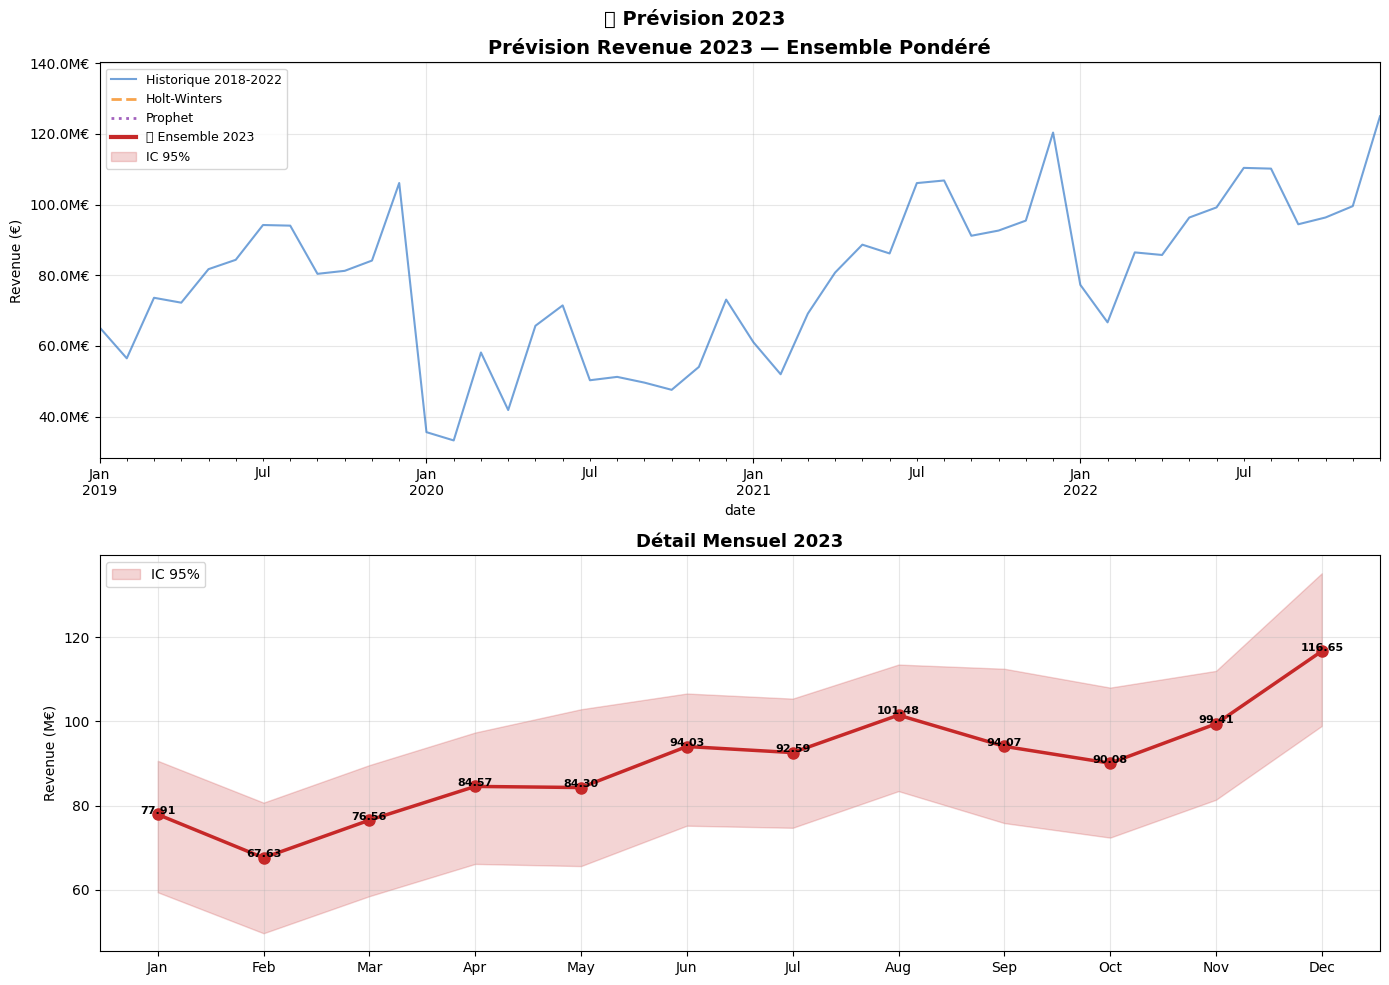

💾 Graphique → forecast_2023.png

📊 Prévisions mensuelles 2023 :
  Mois             Prévision     IC Bas    IC Haut
  -----------------------------------------------
  January 2023       77.91M€    59.45M€    90.64M€
  February 2023      67.63M€    49.72M€    80.72M€
  March 2023         76.56M€    58.52M€    89.62M€
  April 2023         84.57M€    66.18M€    97.36M€
  May 2023           84.30M€    65.66M€   102.87M€
  June 2023          94.03M€    75.25M€   106.60M€
  July 2023          92.59M€    74.75M€   105.39M€
  August 2023       101.48M€    83.45M€   113.47M€
  September 2023     94.07M€    75.87M€   112.48M€
  October 2023       90.08M€    72.42M€   108.01M€
  November 2023      99.41M€    81.40M€   111.97M€
  December 2023     116.65M€    98.91M€   135.14M€
  -----------------------------------------------
  TOTAL 2023       1079.30M€
  TOTAL 2022       1147.52M€
  Variation          -5.9%

💾 Prévisions → forecast_2023.csv


In [ ]:
# Graphique
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

ax = axes[0]
df["revenue"].plot(ax=ax, label="Historique 2018-2022", color="#1565C0", alpha=0.6, linewidth=1.5)
ax.plot(forecast_hw.index, forecast_hw.values, color="#F57C00", linewidth=2.5, linestyle="--", label="Holt-Winters 2023")
ax.fill_between(forecast_hw.index, ic_low_ens, ic_high_ens, alpha=0.2, color="#F57C00", label="IC 95% (bootstrap)")
ax.axvline(pd.Timestamp("2023-01-01"), color="gray", linestyle=":", linewidth=2)
ax.set_title("Prévision Revenue 2023 — Holt-Winters", fontsize=14, fontweight="bold")
ax.set_ylabel("Revenue (€)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M€"))
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax2 = axes[1]
months = forecast_hw.index.strftime("%b")
x = range(12)
ax2.plot(x, ensemble_2023 / 1e6, "o-", color="#F57C00", linewidth=2.5, markersize=8)
ax2.fill_between(x, ic_low_ens / 1e6, ic_high_ens / 1e6, alpha=0.2, color="#F57C00", label="IC 95%")
for i, val in enumerate(ensemble_2023 / 1e6):
    ax2.text(i, val + 0.15, f"{val:.2f}", ha="center", fontsize=8, fontweight="bold")
ax2.set_xticks(x); ax2.set_xticklabels(months)
ax2.set_title("Détail Mensuel 2023", fontsize=13, fontweight="bold")
ax2.set_ylabel("Revenue (M€)"); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle("🔭 Prévision 2023 — Holt-Winters", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("forecast_2023.png", dpi=120, bbox_inches="tight")
plt.show()
print("💾 Graphique → forecast_2023.png")

# Tableau
print("\n📊 Prévisions mensuelles 2023 :")
print(f"  {'Mois':<15} {'Prévision':>10} {'IC Bas':>10} {'IC Haut':>10}")
print("  " + "-"*47)
total = 0
for i, date in enumerate(forecast_hw.index):
    total += ensemble_2023[i]
    print(f"  {date.strftime('%B %Y'):<15} {ensemble_2023[i]/1e6:>8.2f}M€ {ic_low_ens[i]/1e6:>8.2f}M€ {ic_high_ens[i]/1e6:>8.2f}M€")

print("  " + "-"*47)
print(f"  {'TOTAL 2023':<15} {total/1e6:>8.2f}M€")
print(f"  {'TOTAL 2022':<15} {test['revenue'].sum()/1e6:>8.2f}M€")
print(f"  {'Variation':<15} {(total/test['revenue'].sum()-1)*100:>+7.1f}%")

# Sauvegarder
forecast_df = pd.DataFrame({
    "date": forecast_hw.index, "revenue_pred": ensemble_2023,
    "ic_low": ic_low_ens, "ic_high": ic_high_ens
})
forecast_df.to_csv("forecast_2023.csv", index=False)
print("\n💾 Prévisions → forecast_2023.csv")